# Extended Data Fig. 24 - Same-brain validation of optically derived 2D sections against physical histology

WT brains (1 and 9 months; n=1/age) were imaged in 3D, then physically sectioned (80 sections total: 20 sections x 2 stains x 2 ages), stained with DAB (NeuN or Iba1) + Hematoxylin, and computationally mapped to the Neuron Atlas. Cell nuclei on physical sections were detected with StarDist and classified by DAB intensity.

Code panels: physical-section -> Neuron Atlas registration; cell-point region-ID assignment (99.6% of physical NeuN nuclei matched to optical nuclei); NCC of matched vs shifted optical/physical sections; and region-level density correlation between physical-2D and 3D for NeuN and Iba1 (Spearman).

> Schematic/representative-image panels are histology images (not code). Figures preserved from the original run; Japanese stripped; verbose logs removed.

## Input files

| File | Content |
|---|---|
| physical section images (DAB NeuN/Iba1 + Hematoxylin) | input to detection/registration |
| StarDist nuclei detections + DAB-intensity classification | physical-section cells |
| Neuron Atlas reference + ANTs transforms | registration target |
| 3D whole-brain regional densities (WT 1m, 9m) | 3D reference for correlation |

## 1. Physical-section -> Neuron Atlas registration (ANTs)

In [ ]:
#!/usr/bin/env python
# -*- coding:utf-8 -*-
"""
NeuN  -> Atlas    - v18.1 (XY Swap + Hist Swap Test)

-  : NeuN  (CSV)  NeuN->Atlas   ANTs  
        Affine Atlas 
        ANTs 
-  :  fwd.mat + inv.nii.gz  
           whichtoinvert=[True, False]  
-     (v18.1)  
- ants.apply_transforms_to_points   DataFrame   X Y  (v18) 
-   ANTs histogram2d   X, Y   ** **  
- ANTs  [inv_warp, fwd_affine], whichtoinvert=[F, T] (v17 ) 
- Pre/Post ANTs Density Map  
-  :
    - NeuN CSV
    - NeuN->Atlas ANTs  (sXXX_fwd.mat, sXXX_inv.nii.gz)
    - NeuN slice_1.tif ( )
    - NeuN Affine  (sXXX_atlas_affined_template.tif) -  
-  :
    - ANTs  (sXXX_NeuN_points_scaled_pre_ants.tif)
    - ANTs  (sXXX_NeuN_points_mapped_to_affined_atlas_XYSwapInOutTest.tif) <-  
"""

import tifffile
import numpy as np
import os
import glob
from natsort import natsorted
# import h5py
import scipy.io
# import scipy.ndimage
# import skimage.transform
# from scipy.interpolate import interpn
import ants # ANTsPy
from tqdm import tqdm
import pandas as pd
import shutil
import re
import traceback #  
import time #    

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

#
BASE_DATA_PATH = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw"
#
STARDIST_OUTPUT_BASE = os.path.join(BASE_DATA_PATH, "output_stardist")
#
REGISTRATION_FOLDER_NAME = "folder_registration"
#
OUTPUT_DEBUG_FOLDER = "debug_NeuN_points_pre_post_ants_XYSwapInOut" #   v18.1

#
TARGET_NEUN_SAMPLE = "WT_9m_NeuN_Hippocampus"

#
NEUN_THRESHOLD = 0.3

#
SCALE_FACTOR = 0.02

#
SKIP_IF_EXISTS = 0

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
def find_neun_csv(sample_name, slice_id):
    """  NeuN slice_id   CSV  """
    csv_dir = os.path.join(STARDIST_OUTPUT_BASE, sample_name, "csv_results")
    pattern = f"cell_count_results_{slice_id}_thresh{NEUN_THRESHOLD}.csv"
    csv_path = os.path.join(csv_dir, pattern)
    if os.path.exists(csv_path):
        return csv_path, None
    else:
        #
        fallback_pattern = f"cell_count_results_{slice_id}.csv"
        csv_path_alt = os.path.join(csv_dir, fallback_pattern)
        if os.path.exists(csv_path_alt):
             tqdm.write(f"      ->  : Using fallback CSV pattern for {slice_id}: {fallback_pattern}")
             return csv_path_alt, None
        return None, f"NeuN CSV not found for {slice_id} (tried {pattern} and {fallback_pattern})"


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
def main_neun_test():
    """NeuN  -> Atlas   """
    print("--- NeuN Point Mapping Test (v18.1 - XY Swap In & Out Test) ---") #  
    print(f"Target NeuN Sample: {TARGET_NEUN_SAMPLE}")
    print(f"SCALE_FACTOR: {SCALE_FACTOR} (applied BEFORE ANTs)")
    print(f"ANTs Transform: Applying Inv Warp THEN Inv Affine using [inv_warp, fwd_affine] with invert=[F, T]")
    print(f"  Testing with swapped X/Y columns passed to ANTs AND swapped back for histogram  ") #  

    sample_path = os.path.join(BASE_DATA_PATH, TARGET_NEUN_SAMPLE)
    if not os.path.isdir(sample_path):
        print(f" : NeuN : {sample_path}"); return

    #
    debug_output_dir = os.path.join(sample_path, OUTPUT_DEBUG_FOLDER)
    os.makedirs(debug_output_dir, exist_ok=True)
    print(f"  Output Debug Folder: {debug_output_dir}")

    #
    neun_reg_base_path = os.path.join(sample_path, REGISTRATION_FOLDER_NAME)
    if not os.path.isdir(neun_reg_base_path):
        print(f"  ->  : NeuN : {neun_reg_base_path} ")
        return
        
    glob_pattern = os.path.join(neun_reg_base_path, 'folder_dst_s*')
    dst_folders = natsorted(glob.glob(glob_pattern))

    if not dst_folders:
        print(f"  ->  : NeuN  'folder_dst_s*'   (Pattern: {glob_pattern})"); return

    print(f"  {len(dst_folders)}   NeuN  ...")
    
    #
    for ap_histology_dir_neun in tqdm(dst_folders, desc=f"Testing NeuN Mapping (XY Swap In/Out)", unit="slice"): #   tqdm  
        
        slice_processing_start_time = time.time()
        
        folder_basename = os.path.basename(ap_histology_dir_neun)
        match = re.search(r'folder_dst_(s\d+)', folder_basename)
        if not match:
            tqdm.write(f"\n  ->  :   slice_id  : {folder_basename} "); continue
        
        slice_id_neun = match.group(1)
        tqdm.write(f"\n--- Processing NeuN Slice: {slice_id_neun} ---")

        #
        #
        csv_path, csv_err = find_neun_csv(TARGET_NEUN_SAMPLE, slice_id_neun)

        #
        neun_to_atlas_ants_output_dir = os.path.join(ap_histology_dir_neun, f"ants_registration_output_SyN_{slice_id_neun}")
        neun_to_atlas_fwd_affine_path = os.path.join(neun_to_atlas_ants_output_dir, f"{slice_id_neun}_fwd.mat")
        neun_to_atlas_inv_warp_path = os.path.join(neun_to_atlas_ants_output_dir, f"{slice_id_neun}_inv.nii.gz") #   INV Warp  

        #
        neun_affined_template_atlas_path = os.path.join(neun_to_atlas_ants_output_dir, f"{slice_id_neun}_atlas_affined_template.tif")

        #
        neun_slice1_path = os.path.join(ap_histology_dir_neun, 'slice_1.tif')
        
        #
        output_density_pre_ants_path = os.path.join(debug_output_dir, f"{slice_id_neun}_NeuN_points_scaled_pre_ants.tif") # ★ Pre-ANTs
        output_density_post_ants_path = os.path.join(debug_output_dir, f"{slice_id_neun}_NeuN_points_mapped_to_affined_atlas_XYSwapInOutTest.tif") #   Post-ANTs,  

        #
        files_ok = True
        tqdm.write("    Checking required files...")
        required_files_list = [
            (csv_path, f"NeuN CSV"),
            (neun_to_atlas_fwd_affine_path, f"NeuN->Atlas Fwd Affine"),
            (neun_to_atlas_inv_warp_path, f"NeuN->Atlas Inv Warp"),
            (neun_affined_template_atlas_path, f"NeuN Affined Template (for shape)"),
            (neun_slice1_path, f"NeuN slice_1.tif (for shape)"),
        ]
        if csv_err:
             tqdm.write(f"      ->  : {csv_err} ")
             files_ok = False

        for file_path, description in required_files_list:
            if file_path and not os.path.exists(file_path):
                 tqdm.write(f"      ->  : {description} ({os.path.basename(file_path)})  ")
                 files_ok = False

        if not files_ok:
            tqdm.write(f"     : {slice_id_neun}")
            continue

        #
        if SKIP_IF_EXISTS and os.path.exists(output_density_pre_ants_path) and os.path.exists(output_density_post_ants_path):
             tqdm.write(f"     : {slice_id_neun}")
             continue

        tqdm.write(f"    All required files found for {slice_id_neun}.")

        #
        try:
            processing_step_start_time = time.time()
            tqdm.write("    (1/5) Reading NeuN CSV...")
            df_coords = pd.read_csv(csv_path)
            df_coords_clean = df_coords.dropna(subset=['centroid_x', 'centroid_y']).copy()
            if df_coords_clean.empty:
                tqdm.write(f"       -> INFO: NeuN CSV  ")
                continue
            tqdm.write(f"      NeuN CSV read ({len(df_coords_clean)} points) ({time.time() - processing_step_start_time:.2f}s)")

            points_2d_highres = df_coords_clean[['centroid_x', 'centroid_y']].values

            #
            processing_step_start_time = time.time()
            tqdm.write("    (2/5) Scaling points...")
            points_2d_lowres = points_2d_highres * SCALE_FACTOR
            #
            points_df_ants_swapped = pd.DataFrame({
                'x': points_2d_lowres[:, 1], # 'x'  Y 
                'y': points_2d_lowres[:, 0]  # 'y'  X 
            }, index=df_coords_clean.index)
            tqdm.write(f"      Scaling done ({time.time() - processing_step_start_time:.2f}s). Passing swapped X/Y to ANTs.")

            #
            try:
                processing_step_start_time = time.time()
                tqdm.write("    (3/5) Generating PRE-ANTs density map (original XY)...")
                
                #
                try:
                    ref_img_slice1 = tifffile.imread(neun_slice1_path)
                    target_H_s1, target_W_s1 = ref_img_slice1.shape[:2]
                except Exception as e_shape_s1:
                     tqdm.write(f"       ->  :   ({os.path.basename(neun_slice1_path)})  : {e_shape_s1} Pre-ANTs ")
                     raise

                #
                points_x_pre = points_2d_lowres[:, 0] #  X
                points_y_pre = points_2d_lowres[:, 1] #  Y
                
                density_map_pre, _, _ = np.histogram2d(
                    points_x_pre, points_y_pre,
                    bins=(target_W_s1, target_H_s1),
                    range=[[0, target_W_s1-1], [0, target_H_s1-1]]
                )
                
                tifffile.imwrite(output_density_pre_ants_path, density_map_pre.T.astype(np.float32))
                tqdm.write(f"      PRE-ANTs density map saved ({time.time() - processing_step_start_time:.2f}s).")

            except Exception as e_hist_pre:
                tqdm.write(f"       ->  : PRE-ANTs  : {e_hist_pre}\n{traceback.format_exc()}")
                #
            #


            #
            #
            transform_list_apply = [
                neun_to_atlas_fwd_affine_path, # T2 ( ) -> inv Affine (whichtoinvert=True)
                neun_to_atlas_inv_warp_path    # T1 ( ) -> inv Warp (whichtoinvert=False)
            ]
            points_on_affined_atlas = None #  
            try:
                processing_step_start_time = time.time()
                tqdm.write(f"    (4/5) Applying ANTs transform (NeuN->Atlas, inv Warp then inv Aff, XY SWAPPED input)...")
                points_on_affined_atlas = ants.apply_transforms_to_points(
                    dim=2, points=points_df_ants_swapped, #   XY  DF  
                    transformlist=transform_list_apply,
                    whichtoinvert=[True, False], #    : Affine=T, Warp=F
                    verbose=True
                )
                tqdm.write(f"      ANTs transform applied ({time.time() - processing_step_start_time:.2f}s).")
                if points_on_affined_atlas is None or not isinstance(points_on_affined_atlas, pd.DataFrame):
                     raise ValueError("apply_transforms_to_points returned invalid result.")
            except Exception as e_ants:
                tqdm.write(f"\n★★★ ANTs Error (apply_transforms_to_points): {e_ants}\n{traceback.format_exc()}")
                continue

            #
            try:
                processing_step_start_time = time.time()
                tqdm.write("    (5/5) Generating POST-ANTs density map (swapping XY back for histogram)...") #    
                
                #
                try:
                    ref_img_affine = tifffile.imread(neun_affined_template_atlas_path)
                    target_H_aff, target_W_aff = ref_img_affine.shape[:2]
                except Exception as e_shape_aff:
                     tqdm.write(f"       ->  :   ({os.path.basename(neun_affined_template_atlas_path)})  : {e_shape_aff} Post-ANTs ")
                     continue

                #
                #
                points_x_post = points_on_affined_atlas['y'].values #   'y'   ( X )   X  
                points_y_post = points_on_affined_atlas['x'].values #   'x'   ( Y )   Y  
                
                density_map_post, _, _ = np.histogram2d(
                    points_x_post, points_y_post,
                    bins=(target_W_aff, target_H_aff),
                    range=[[0, target_W_aff-1], [0, target_H_aff-1]]
                )
                
                tifffile.imwrite(output_density_post_ants_path, density_map_post.T.astype(np.float32))
                tqdm.write(f"      POST-ANTs density map saved ({time.time() - processing_step_start_time:.2f}s).")

            except Exception as e_hist_post:
                tqdm.write(f"       ->  : POST-ANTs  : {e_hist_post}\n{traceback.format_exc()}")
                continue
            #

        except Exception as e:
            #
            tqdm.write(f"\n    (NeuN Slice: {slice_id_neun}  ): {e}\n{traceback.format_exc()}")
            continue #  
            
        tqdm.write(f"--- NeuN Slice: {slice_id_neun} processed in {time.time() - slice_processing_start_time:.2f}s ---")

    print("\n---     NeuN   ---")

if __name__ == '__main__':
    main_neun_test()



## 2. Cell-point region-ID assignment (cKDTree); 99.6% of physical NeuN nuclei matched

In [ ]:
#!/usr/bin/env python
# -*- coding:utf-8 -*-

import pandas as pd
import numpy as np
import os
import glob
from natsort import natsorted
from scipy.spatial import cKDTree
import tifffile
import gc
from tqdm import tqdm

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

#
BASE_DATA_PATH = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw"

#
TARGET_SAMPLES = [
    "WT_9m_NeuN_Hippocampus",
    #"WT_1m_NeuN_Hippocampus",
    #"WT_9m_NeuN_Cortex1",
    #"WT_1m_NeuN_Cortex1",
]

#
ANALYSIS_OUTPUT_BASE = "NeuN_stardist_analysis_output"

#
#
PATH_ANNOTATION_VOLUME = '/data4/Neurology_project_data_archive/atlas/annotation_10_LUT_modified_final.tif'


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

def add_annotation_ids_to_cell_csvs():
    """
    cKDTree  NeuN   CSV  'annotation_id'  
    """
    print("\n---  : cKDTree ID    ---")
    
    #
    try:
        annotation_vol = tifffile.imread(PATH_ANNOTATION_VOLUME)
        print(f"  ->  : {PATH_ANNOTATION_VOLUME} (Shape: {annotation_vol.shape})")
    except FileNotFoundError:
        print(f"   :  : {PATH_ANNOTATION_VOLUME}")
        return
    except Exception as e:
        print(f"   :  : {e}")
        return
        
    coords = np.argwhere(annotation_vol > 0)
    if coords.size == 0:
        print(f"   :   ( > 0 ) ID ")
        return
        
    values = annotation_vol[coords[:, 0], coords[:, 1], coords[:, 2]]
    
    #
    df_non_zero = pd.DataFrame(coords, columns=['AP', 'DV', 'ML'])
    df_non_zero['id'] = values
    
    #
    df_non_zero[['AP', 'DV', 'ML']] = df_non_zero[['AP', 'DV', 'ML']].astype(np.float32) + 0.5
    
    #
    print(f"  -> {len(df_non_zero)} cKDTree ...")
    tree_points = df_non_zero[['AP', 'DV', 'ML']].values
    tree = cKDTree(tree_points)
    print("  -> cKDTree ")
    
    #
    first_sample_printed = False
    
    #
    for sample_name in tqdm(TARGET_SAMPLES, desc=" "):
        
        #
        csv_path = os.path.join(
            BASE_DATA_PATH, sample_name, 
            ANALYSIS_OUTPUT_BASE, # "NeuN_stardist_analysis_output"
            "mapped_to_3d",
            f"ALL_SLICES_{sample_name}_mapped_3d_original_coords.csv" # "ALL_SLICES_..."
        )
        
        #
        output_csv_path = os.path.join(
            BASE_DATA_PATH, sample_name, 
            ANALYSIS_OUTPUT_BASE, 
            "mapped_to_3d",
            f"ALL_SLICES_{sample_name}_mapped_3d_original_coords_annotated.csv" #     "_annotated"  
        )
        
        if not os.path.exists(csv_path):
            tqdm.write(f"  ->  :  CSV  ( ): {csv_path}")
            continue
            
        try:
            df_points = pd.read_csv(csv_path)
        except Exception as e:
            tqdm.write(f"  ->  : CSV  ({sample_name}): {e}")
            continue

        if df_points.empty:
            tqdm.write(f"  -> INFO: CSV  ({sample_name}) ")
            continue
        
        if 'original_AP' not in df_points.columns:
            tqdm.write(f"  ->  : 'original_AP'   ( ): {sample_name}")
            continue

        #
        point_coords = df_points[['original_AP', 'original_DV', 'original_ML']].values.astype(np.float32)
        distances, indexes = tree.query(point_coords, k=1, n_jobs=-1)
        
        #
        df_points['annotation_id'] = df_non_zero.iloc[indexes]['id'].values
        
        #
        if not first_sample_printed:
            tqdm.write(f"\n--- {sample_name}  CSV  ( 5 ) ---")
            #
            tqdm.write(df_points.head(5).to_string())
            tqdm.write("--- ( ) ---\n")
            first_sample_printed = True #  
        
        #
        try:
            #
            df_points.to_csv(output_csv_path, index=False)
            tqdm.write(f"  ->  : {sample_name}  CSV : \n     {output_csv_path}")
        except Exception as e:
            tqdm.write(f"  ->  : CSV  ({sample_name}): {e}")
            
    #
    del tree, tree_points, df_non_zero, annotation_vol, coords, values
    gc.collect()
    print("---  : C ---")


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

if __name__ == '__main__':
    
    print("=== NeuN  ID  (cKDTree) ===")
    
    if not os.path.exists(PATH_ANNOTATION_VOLUME):
        print(f"   :  ")
        print(f" : {PATH_ANNOTATION_VOLUME}")
        print(" ")
    else:
        try:
            add_annotation_ids_to_cell_csvs()
            print("\n---     ---")
        except Exception as e:
            print(f"\n   :  ")
            import traceback
            traceback.print_exc()

## 3. NCC of matched vs shifted optical/physical sections

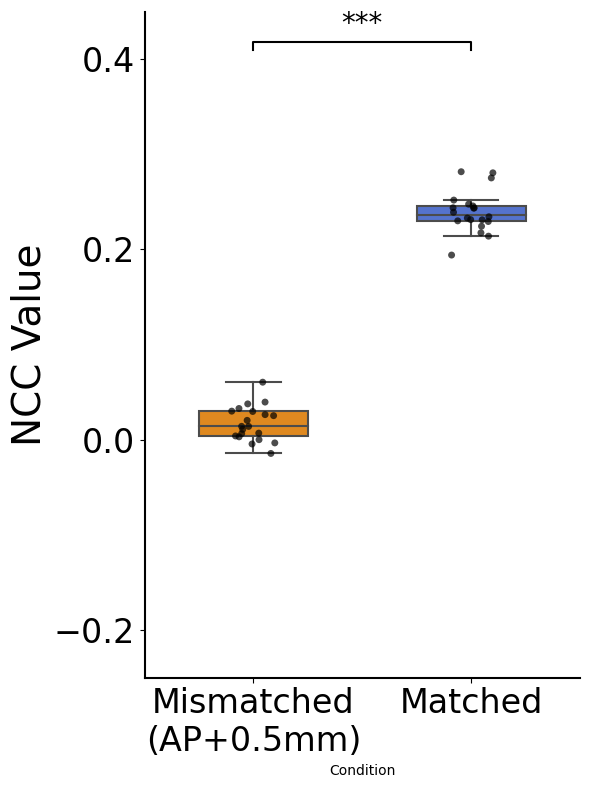

In [1]:
import pandas as pd
import numpy as np
import os
import glob
from natsort import natsorted
import re
import tifffile
from scipy.ndimage import uniform_filter
from tqdm import tqdm
from skimage.transform import rescale
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import wilcoxon #     (Wilcoxon)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

#
BASE_DATA_PATH = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw"
STARDIST_OUTPUT_BASE = os.path.join(BASE_DATA_PATH, "output_stardist")
REGISTRATION_FOLDER_NAME = "folder_registration"

#
AP_SHIFT_AMOUNT = 50

#
CSV_DIR = os.path.join(STARDIST_OUTPUT_BASE, "combined_simulation_plots")

#
CSV_PATH_CORRECT = os.path.join(CSV_DIR, "ncc_atlas_vs_debug_density_50um.csv")
COLUMN_NAME_CORRECT = "ncc_mean_50um"
LABEL_CORRECT = "Matched"

#
SHIFT_SUFFIX = f"AP_plus_{AP_SHIFT_AMOUNT}"
CSV_PATH_SHIFTED = os.path.join(CSV_DIR, f"ncc_atlas_vs_debug_density_50um_{SHIFT_SUFFIX}.csv")
COLUMN_NAME_SHIFTED = f"ncc_mean_50um_{SHIFT_SUFFIX}"
LABEL_SHIFTED = f"Mismatched\n(AP+0.5mm)"

#
OUTPUT_PDF_PATH = os.path.join("/data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/2D_Physical_slice_analysis/", f"ncc_comparison_boxplot_{SHIFT_SUFFIX}_mismatch_first.pdf") #    


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

def main_compare_ncc():
    print("--- NCC   &   (Mismatch ) ---")
    
    try:
        #
        print(f"Loading Correct data: {CSV_PATH_CORRECT}")
        df_correct = pd.read_csv(CSV_PATH_CORRECT)
        
        print(f"Loading Shifted data: {CSV_PATH_SHIFTED}")
        df_shifted = pd.read_csv(CSV_PATH_SHIFTED)

    except FileNotFoundError as e:
        print(f"!!!  :  CSV : {e.filename}")
        return
    except Exception as e:
        print(f"!!!  : CSV : {e}")
        return

    #
    df_correct_slim = df_correct[['slice_id', COLUMN_NAME_CORRECT]].rename(columns={COLUMN_NAME_CORRECT: LABEL_CORRECT})
    df_shifted_slim = df_shifted[['slice_id', COLUMN_NAME_SHIFTED]].rename(columns={COLUMN_NAME_SHIFTED: LABEL_SHIFTED})
    
    df_merged = pd.merge(df_correct_slim, df_shifted_slim, on='slice_id', how='inner')
    
    #
    df_test = df_merged.dropna()
    
    if df_test.empty:
        print("!!!  :  ")
        return
        
    print(f"\n{len(df_test)}  ")

    #
    p_value = np.nan
    try:
        #
        diff = df_test[LABEL_SHIFTED] - df_test[LABEL_CORRECT]
        df_test_wilcoxon = df_test[diff != 0]
        
        if len(df_test_wilcoxon) > 0:
            #
            stat, p_value = wilcoxon(df_test_wilcoxon[LABEL_SHIFTED], df_test_wilcoxon[LABEL_CORRECT])
            print(f"\n--- Wilcoxon Paired Test (N={len(df_test_wilcoxon)}) ---")
            print(f"  Statistic: {stat:.2f}")
            print(f"  P-value: {p_value:.4g}")
        else:
            print("\n--- Wilcoxon Paired Test ---")
            print("   0 ")
            
    except Exception as e:
        print(f"!!!  : {e}")

    #
    df_long = df_test.melt(
        id_vars=['slice_id'], 
        value_vars=[LABEL_SHIFTED, LABEL_CORRECT], #    
        var_name='Condition', 
        value_name='NCC Value' 
    )

    #
    print("\n ...")
    
    plt.style.use('default')
    matplotlib.rcParams['pdf.use14corefonts'] = True
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    plt.rcParams['axes.linewidth'] = 1.5
    
    fig, ax = plt.subplots(figsize=(6, 8)) 

    #
    sns.boxplot(
        data=df_long, 
        x='Condition', 
        y='NCC Value', 
        ax=ax,
        palette=["darkorange", "royalblue"], #    
        width=0.5,
        showfliers=False 
    )
    
    #
    sns.stripplot(
        data=df_long, 
        x='Condition', 
        y='NCC Value', 
        ax=ax,
        color='black',
        alpha=0.7, 
        jitter=0.1
    )

    #
    #ax.set_xlabel('Alignment Condition', fontsize=28)
    ax.set_ylabel('NCC Value', fontsize=28) 
    ax.tick_params(axis='both', which='major', labelsize=24)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    #
    ax.set_ylim(-0.25, 0.45) 
    ax.set_yticks([-0.2, 0.0, 0.2, 0.4])

    #
    if not np.isnan(p_value):
        if p_value < 0.001:
            p_text = "***"
        else:
            p_text = f"p = {p_value:.4g}"
            
        y_pos = 0.41 # Y  (0.45)  
        #
        ax.plot([0, 0, 1, 1], [y_pos, y_pos*1.02, y_pos*1.02, y_pos], lw=1.5, c='black')
        ax.text(0.5, y_pos*1.03, p_text, ha='center', va='bottom', fontsize=20)
        
    plt.tight_layout()

    #
    try:
        plt.savefig(
            OUTPUT_PDF_PATH,
            transparent=True, 
            dpi=300, 
            bbox_inches='tight', 
            pad_inches=0.1
        )
        print(f"\n---     ---")
        print(f"  {OUTPUT_PDF_PATH}  ")
        plt.show()

    except Exception as e:
        print(f"!!!  :  : {e}")


if __name__ == '__main__':
    main_compare_ncc()

## 4. Physical-2D vs 3D regional density correlation - NeuN (Spearman)

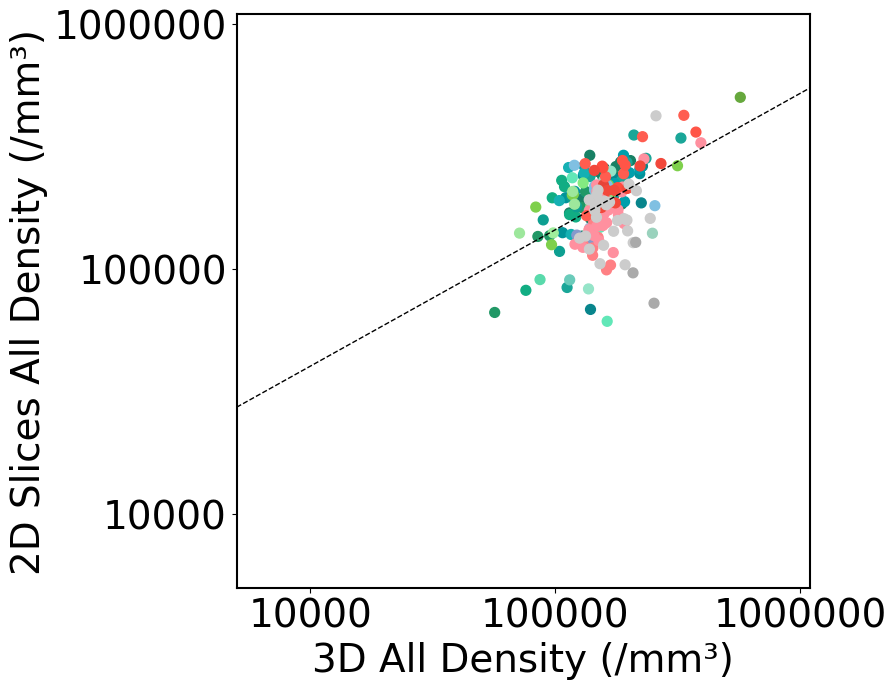

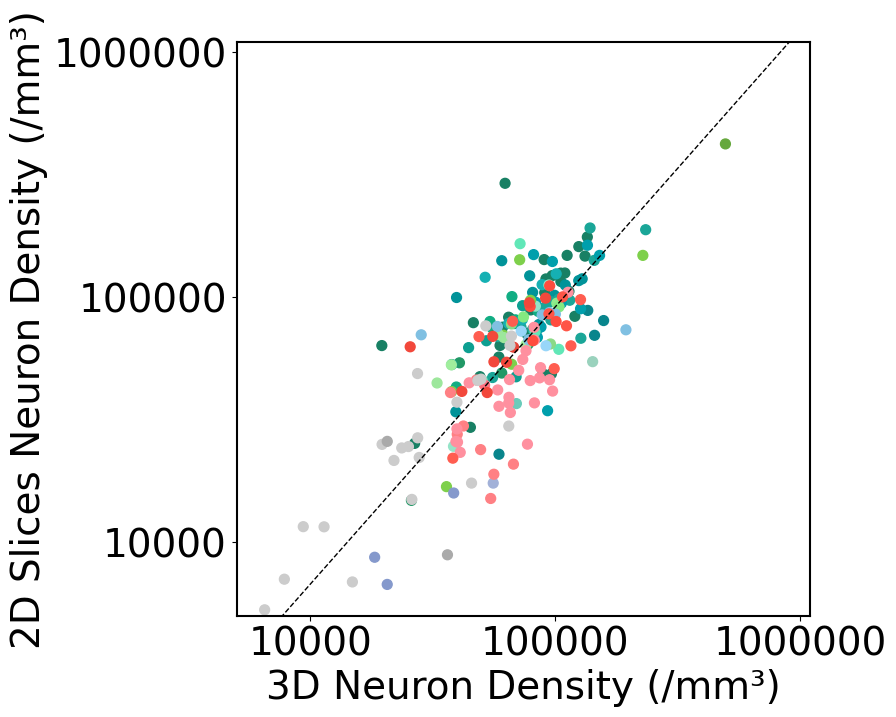

In [2]:

#!/usr/bin/env python
# -*- coding:utf-8 -*-

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import spearmanr
import os
import matplotlib.ticker as mticker
from tqdm import tqdm

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

#
BASE_DATA_PATH = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw"
STARDIST_OUTPUT_BASE = os.path.join(BASE_DATA_PATH, "output_stardist")
TARGET_NEUN_SAMPLE = "WT_9m_NeuN_Hippocampus" #   aggregate_region_counts.py  
PATH_2D_DATA_DIR = os.path.join(STARDIST_OUTPUT_BASE, TARGET_NEUN_SAMPLE, "region_aggregation_results")

#
PATH_3D_DATA = "/data4/Neurology_project_data_archive/temp_from_ds1_Imaging3/#5_APPmodel_Ctr9m_3_2023_0322_2014/intensities_/Regional_cellome4.csv"

#
COLOR_MAP_PATH = "/data4/ds1_Imaging3/atlas_for_fig/GOvsID_6region_removed.csv"

#
SLICE_THICKNESS_Z_UM = 12 # (um) ( )

#
PLOT_OUTPUT_DIR = os.path.join("/data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/2D_Physical_slice_analysis/", "2d_vs_3d_correlation_plots")
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

#
AXIS_MIN_VAL = 5000
AXIS_MAX_VAL = 1000000 * 1.1

#
MIN_SLICES_WITH_DATA = 1# ( )

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

#
def calculate_2d_density_from_area(df_area_sum_um2, df_count_sum, slice_thickness_um):
    """
     (um^2) (/mm^3) 
    """
    total_volume_um3 = df_area_sum_um2 * slice_thickness_um
    total_volume_mm3 = total_volume_um3 * 1e-9
    density = np.where(
        total_volume_mm3 > 1e-12, #  
        df_count_sum / total_volume_mm3,
        0
    )
    return pd.Series(density, index=df_area_sum_um2.index)

def load_3d_data(path_3d, cell_type):
    """3D CSV """
    df_3d = pd.read_csv(path_3d)
    if cell_type == "All": col_name = "All cell density (/mm3)"
    elif cell_type == "NeuN": col_name = "NeuN+ density (/mm3)"
    else: raise ValueError(f"  cell_type: {cell_type}")
    if col_name not in df_3d.columns: raise ValueError(f"3D CSV  '{col_name}'  ")
    df_3d = df_3d.set_index('atlasID')
    return df_3d[col_name]

def plot_correlation(df_merged, df_colors, cell_type, output_pdf_path):
    """2D vs 3D  """
    print(f"--- {cell_type}   ---")
    df_plot = df_merged.dropna()
    df_plot = df_plot[(df_plot['3d_mean'] > 0) & (df_plot['2d_mean'] > 0)]
    if df_plot.empty: print(" :  0 "); return

    df_plot = df_plot.merge(df_colors[['id', 'color']], left_index=True, right_on='id', how='left')
    df_plot['color'] = df_plot['color'].apply(lambda x: (0.7, 0.7, 0.7) if pd.isnull(x) else x)

    corr, p_value = spearmanr(df_plot['3d_mean'], df_plot['2d_mean'])
    print(f"  {cell_type} Spearman Correlation: {corr:.4f} (p-value: {p_value:.4g})")

    plt.style.use('default')
    matplotlib.rcParams['pdf.use14corefonts'] = True
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.scatter(df_plot['3d_mean'], df_plot['2d_mean'], alpha=1, s=50, c=df_plot['color'])

    #
    log_3d = np.log10(df_plot['3d_mean'].replace(0, np.nan).dropna()) # 0 NaN 
    log_2d = np.log10(df_plot['2d_mean'].replace(0, np.nan).dropna()) # 0 NaN 
    common_index = log_3d.index.intersection(log_2d.index) #  
    if len(common_index) > 1: # 2 
        m, c = np.polyfit(log_3d[common_index], log_2d[common_index], 1)
        x_fit = np.array([AXIS_MIN_VAL,  AXIS_MAX_VAL])  #  
        y_fit = 10**(m * np.log10(x_fit) + c)
        ax.plot(x_fit, y_fit, color='black', linewidth=1, linestyle='--')
    else:
        print(f"  ( : {cell_type}  2 )")


    ax.set_xscale('log')
    ax.set_yscale('log')
    xlabel = f'3D {cell_type} Density (/mm³)' if cell_type == "All" else '3D Neuron Density (/mm³)'
    ylabel = f'2D Slices {cell_type} Density (/mm³)' if cell_type == "All" else '2D Slices Neuron Density (/mm³)'
    ax.set_xlabel(xlabel, fontsize=28)
    ax.set_ylabel(ylabel, fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.set_xlim(AXIS_MIN_VAL, AXIS_MAX_VAL)
    ax.set_ylim(AXIS_MIN_VAL, AXIS_MAX_VAL)
    ax.set_aspect('equal', adjustable='box')
    major_ticks = [10000, 100000, 1000000]
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(mticker.ScalarFormatter())
        axis.get_major_formatter().set_scientific(False)
        axis.set_minor_locator(mticker.NullLocator())
    plt.tight_layout()

    plt.savefig(output_pdf_path, transparent=True, dpi=300)
    print(f"   : {output_pdf_path}")
    plt.show()
    plt.close(fig)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
if __name__ == "__main__":

    print(f"--- 2D vs 3D   (v1.3 - region_areas_um2 +  ) ---")
    print(f"2D : {PATH_2D_DATA_DIR}")
    print(f"3D : {PATH_3D_DATA}")
    print(f" : {PLOT_OUTPUT_DIR}")

    try:
        #
        print("2D ...")
        path_area = os.path.join(PATH_2D_DATA_DIR, "region_areas_um2.csv")
        df_area = pd.read_csv(path_area, index_col='slice_id')
        path_total = os.path.join(PATH_2D_DATA_DIR, "total_cell_counts.csv")
        df_total = pd.read_csv(path_total, index_col='slice_id')
        path_neun = os.path.join(PATH_2D_DATA_DIR, "neun_positive_cell_counts.csv")
        df_neun = pd.read_csv(path_neun, index_col='slice_id')

        #
        df_area_mask = (df_area > 1e-6).sum(axis=0) >= MIN_SLICES_WITH_DATA
        df_total_mask = (df_total > 0).sum(axis=0) >= MIN_SLICES_WITH_DATA
        df_neun_mask = (df_neun > 0).sum(axis=0) >= MIN_SLICES_WITH_DATA
        valid_mask_all = df_area_mask & df_total_mask
        valid_mask_neun = df_area_mask & df_neun_mask
        print(f"\n  ({MIN_SLICES_WITH_DATA} ):")
        print(f"    'All' (Area & Total > 0): {valid_mask_all.sum()} / {len(valid_mask_all)}  ")
        print(f"    'NeuN' (Area & NeuN > 0): {valid_mask_neun.sum()} / {len(valid_mask_neun)}  ")

        #
        df_area_sum_um2 = df_area.sum(axis=0)
        df_total_count_sum = df_total.sum(axis=0)
        df_neun_count_sum = df_neun.sum(axis=0)

        #
        print("2D  ( )...")
        density_2d_all = calculate_2d_density_from_area(
            df_area_sum_um2[valid_mask_all], df_total_count_sum[valid_mask_all], SLICE_THICKNESS_Z_UM)
        density_2d_neun = calculate_2d_density_from_area(
            df_area_sum_um2[valid_mask_neun], df_neun_count_sum[valid_mask_neun], SLICE_THICKNESS_Z_UM)

        #
        print(" ...")
        df_colors = pd.read_csv(COLOR_MAP_PATH)
        df_colors = df_colors[['id', 'R', 'G', 'B']]
        df_colors['color'] = df_colors.apply(lambda row: (row['R']/255, row['G']/255, row['B']/255), axis=1)

        #
        cell_types_to_process = ["All", "NeuN"]
        for cell_type in tqdm(cell_types_to_process, desc="Processing cell types"):
            density_2d = density_2d_all if cell_type == "All" else density_2d_neun
            density_2d.name = "2d_mean"
            density_2d.index = density_2d.index.astype(str)

            density_3d = load_3d_data(PATH_3D_DATA, cell_type)
            density_3d.name = "3d_mean"
            density_3d.index = density_3d.index.astype(str)

            df_merged = pd.DataFrame(density_2d).join(density_3d, how='inner')
            
            #
            #
            df_compare = df_merged.dropna()
            df_compare = df_compare[(df_compare['3d_mean'] > 1e-9) & (df_compare['2d_mean'] > 1e-9)] #  
            
            if not df_compare.empty:
                lower_bound = df_compare['3d_mean'] * 0.9
                upper_bound = df_compare['3d_mean'] * 1.1
                within_10_percent = (
                    (df_compare['2d_mean'] >= lower_bound) & 
                    (df_compare['2d_mean'] <= upper_bound)
                )
                count_within = within_10_percent.sum()
                total_compared = len(df_compare)
                percentage_within = (count_within / total_compared) * 100 if total_compared > 0 else 0
                
                print(f"\n--- {cell_type}   (±10%) ---")
                print(f"   : {total_compared}")
                print(f"   : {count_within}")
                print(f"   : {percentage_within:.2f}%")
            else:
                 print(f"\n--- {cell_type}   (±10%) ---")
                 print("   ")
            #

            #
            df_merged.index = df_merged.index.astype(int) 
            output_pdf = os.path.join(
                PLOT_OUTPUT_DIR,
                f"correlation_3d_vs_2d_{TARGET_NEUN_SAMPLE}_{cell_type}_density_loglog_colored_v1_3_9m.pdf" # ver 
            )
            plot_correlation(df_merged, df_colors, cell_type, output_pdf)

    except FileNotFoundError as e:
        print(f"\n!!!  :  ")
        print(f" : {e}")
        print(" CSV (region_areas_um2.csv, *_cell_counts.csv, Regional_cellome4.csv, GOvsID_*.csv)  ")
    except Exception as e:
        print(f"\n!!!  :  ")
        import traceback
        print(traceback.format_exc())

    print("\n===   ===")

## 5. Physical-2D vs 3D regional density correlation - Iba1 (Spearman)

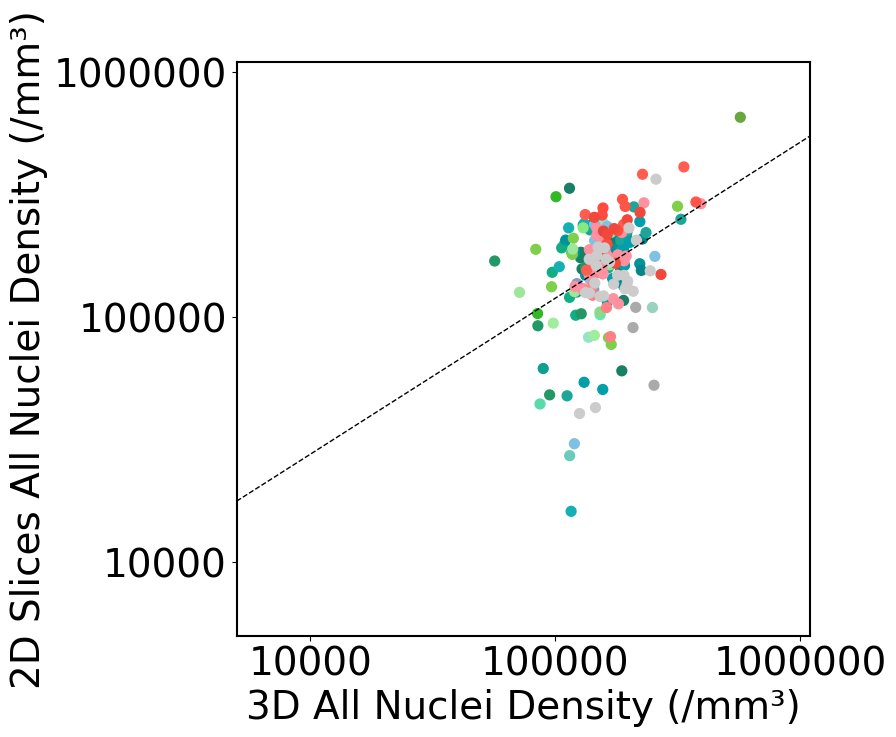

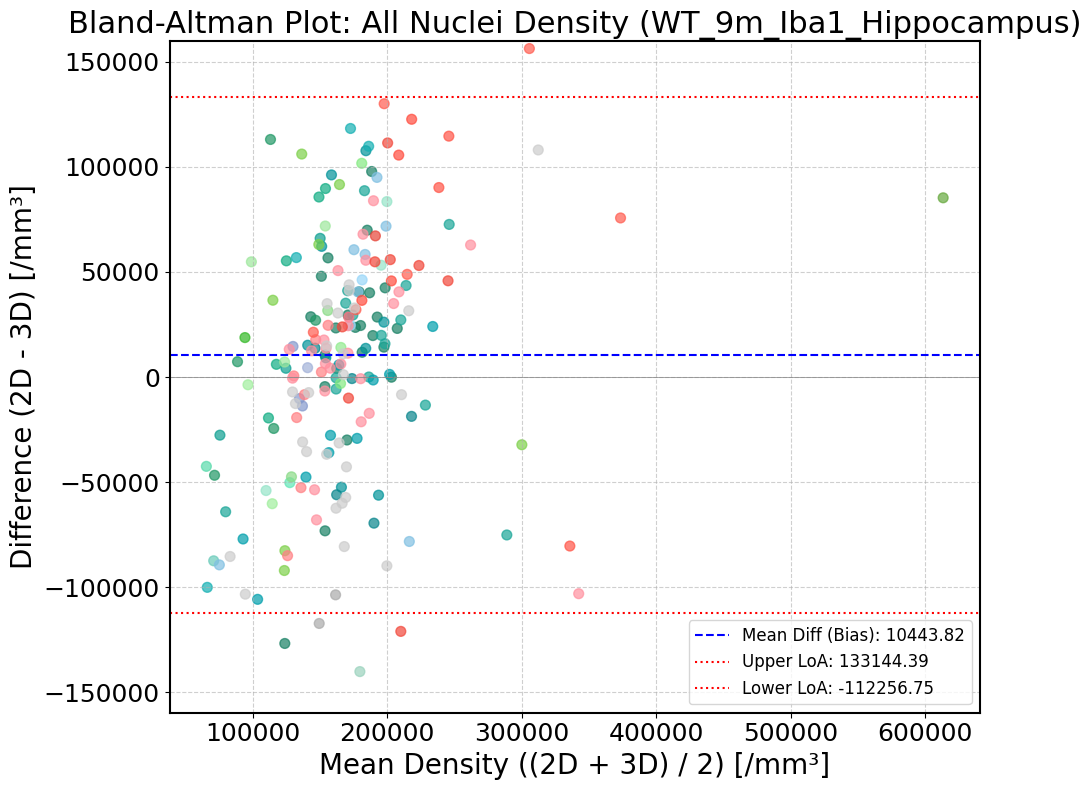

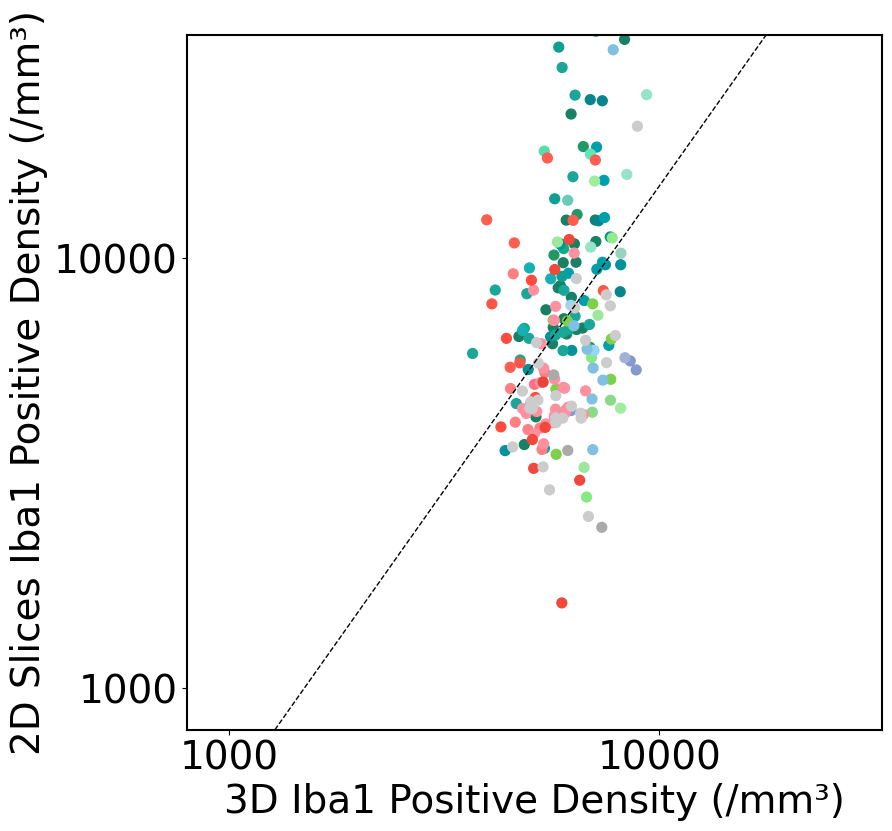

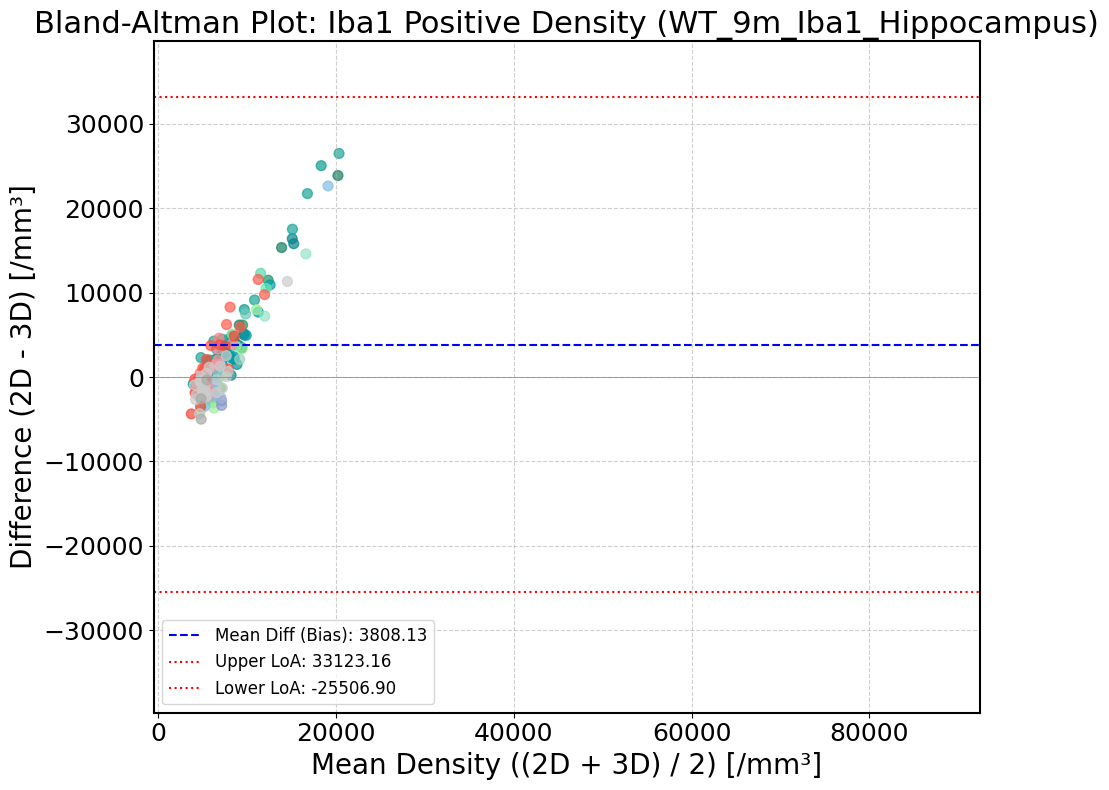

In [3]:
#!/usr/bin/env python
# -*- coding:utf-8 -*-

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import spearmanr, ttest_rel # spearmanr  
from statsmodels.stats.weightstats import ttost_paired
import os
import matplotlib.ticker as mticker
from tqdm import tqdm

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

#
BASE_DATA_PATH = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw"
STARDIST_OUTPUT_BASE = os.path.join(BASE_DATA_PATH, "output_stardist")
TARGET_SAMPLE = "WT_9m_Iba1_Hippocampus" #   Iba1  
PATH_2D_DATA_DIR = os.path.join(STARDIST_OUTPUT_BASE, TARGET_SAMPLE, "region_aggregation_results")

#
PATH_3D_DATA = "/data4/Neurology_project_data_archive/temp_from_ds1_Imaging3/#5_APPmodel_Ctr9m_3_2023_0322_2014/intensities_/Regional_cellome4.csv"

#
COLOR_MAP_PATH = "/data4/ds1_Imaging3/atlas_for_fig/GOvsID_6region_removed.csv"

#
SLICE_THICKNESS_Z_UM = 12 # (um) ( )

#
PLOT_OUTPUT_DIR = os.path.join("/data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/2D_Physical_slice_analysis/", "2d_vs_3d_correlation_plots")
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

#
#
# AXIS_MIN_VAL_CORR = 100 
# AXIS_MAX_VAL_CORR = 1000000 * 1.1

#
MIN_SLICES_WITH_DATA = 1 # ( )

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
def calculate_2d_density_from_area(df_area_sum_um2, df_count_sum, slice_thickness_um):
    """ (um^2) (/mm^3) """
    total_volume_um3 = df_area_sum_um2 * slice_thickness_um
    total_volume_mm3 = total_volume_um3 * 1e-9
    density = np.where(total_volume_mm3 > 1e-12, df_count_sum / total_volume_mm3, 0)
    return pd.Series(density, index=df_area_sum_um2.index)

def load_3d_data(path_3d, cell_type):
    """3D CSV """
    df_3d = pd.read_csv(path_3d)
    if cell_type == "All Nuclei": col_name = "All cell density (/mm3)"
    elif cell_type == "Iba1 Positive": col_name = "Iba1+ density (/mm3)"
    else: raise ValueError(f"  cell_type: {cell_type}")
    if col_name not in df_3d.columns: raise ValueError(f"3D CSV  '{col_name}'  ")
    df_3d = df_3d.set_index('atlasID')
    return df_3d[col_name]

def plot_correlation(df_merged, df_colors, cell_type, output_pdf_path):
    """2D vs 3D   (  v1.10    )"""
    print(f"--- {cell_type}   ---")
    df_plot = df_merged.dropna()
    df_plot = df_plot[(df_plot['3d_mean'] > 0) & (df_plot['2d_mean'] > 0)]
    if df_plot.empty: print(" :  0 "); return

    df_plot = df_plot.merge(df_colors[['id', 'color']], left_index=True, right_on='id', how='left')
    df_plot['color'] = df_plot['color'].apply(lambda x: (0.7, 0.7, 0.7) if pd.isnull(x) else x)

    # --- --- --- --- --- --- --- --- --- --- --- --- --- ---
    #
    if cell_type == "All Nuclei":
        axis_min_val = 5000
        axis_max_val = 1000000 * 1.1
        major_ticks = [10000, 100000, 1000000]
    elif cell_type == "Iba1 Positive":
        axis_min_val = 800
        axis_max_val = 30000 * 1.1
        major_ticks = [1000, 10000] # 30000*1.1 (33000) 100000 
    else:
        #
        print(f" : {cell_type}  ")
        axis_min_val = 100
        axis_max_val = 1000000 * 1.1
        major_ticks = [100, 1000, 10000, 100000, 1000000]
    # --- --- --- --- --- --- --- --- --- --- --- --- --- ---

    plt.style.use('default')
    matplotlib.rcParams['pdf.use14corefonts'] = True; matplotlib.rcParams['font.family'] = 'Arial'; matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.scatter(df_plot['3d_mean'], df_plot['2d_mean'], alpha=1, s=50, c=df_plot['color'])

    log_3d = np.log10(df_plot['3d_mean'].replace(0, np.nan).dropna())
    log_2d = np.log10(df_plot['2d_mean'].replace(0, np.nan).dropna())
    common_index = log_3d.index.intersection(log_2d.index)
    if len(common_index) > 1:
        m, c = np.polyfit(log_3d[common_index], log_2d[common_index], 1)
        #
        x_fit = np.array([axis_min_val, axis_max_val]) 
        y_fit = 10**(m * np.log10(x_fit) + c)
        ax.plot(x_fit, y_fit, color='black', linewidth=1, linestyle='--')
    else: print(f"  ( : {cell_type}  )")

    ax.set_xscale('log'); ax.set_yscale('log')
    xlabel = f'3D {cell_type} Density (/mm³)'; ylabel = f'2D Slices {cell_type} Density (/mm³)'
    ax.set_xlabel(xlabel, fontsize=28); ax.set_ylabel(ylabel, fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)
    
    #
    ax.set_xlim(axis_min_val, axis_max_val); ax.set_ylim(axis_min_val, axis_max_val)
    ax.set_aspect('equal', adjustable='box')

    # --- --- --- --- --- --- --- --- --- --- --- --- --- ---
    #
    # --- --- --- --- --- --- --- --- --- --- --- --- --- ---
    
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)

    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(mticker.ScalarFormatter()); axis.get_major_formatter().set_scientific(False)
        axis.set_minor_locator(mticker.NullLocator())
    
    #
    
    # --- --- --- --- --- --- --- --- --- --- --- --- --- ---

    plt.tight_layout(); plt.savefig(output_pdf_path, transparent=True, dpi=300)
    print(f"   : {output_pdf_path}"); plt.show(); plt.close(fig)

def plot_bland_altman(df_merged, df_colors, cell_type, output_pdf_path):
    """Bland-Altman   (     )"""
    print(f"--- {cell_type}   Bland-Altman   ---")
    df_plot = df_merged.dropna()
    df_plot = df_plot[(df_plot['3d_mean'] > 1e-9) & (df_plot['2d_mean'] > 1e-9)]
    if df_plot.empty: print(" : Bland-Altman  0 "); return

    means = (df_plot['2d_mean'] + df_plot['3d_mean']) / 2
    diffs = df_plot['2d_mean'] - df_plot['3d_mean']
    mean_diff = np.mean(diffs); std_diff = np.std(diffs, ddof=1)
    loa_upper = mean_diff + 1.96 * std_diff; loa_lower = mean_diff - 1.96 * std_diff
    print(f"  {cell_type} Bland-Altman:"); print(f"    Mean Difference (Bias): {mean_diff:.2f}")
    print(f"    Std Dev of Difference: {std_diff:.2f}"); print(f"    Limits of Agreement (LoA): [{loa_lower:.2f}, {loa_upper:.2f}]")

    df_plot = df_plot.merge(df_colors[['id', 'color']], left_index=True, right_on='id', how='left')
    df_plot['color'] = df_plot['color'].apply(lambda x: (0.7, 0.7, 0.7) if pd.isnull(x) else x)

    plt.style.use('default'); matplotlib.rcParams['pdf.use14corefonts'] = True
    matplotlib.rcParams['font.family'] = 'Arial'; matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(means, diffs, alpha=0.7, s=50, c=df_plot['color'])
    ax.axhline(mean_diff, color='blue', linestyle='--', linewidth=1.5, label=f'Mean Diff (Bias): {mean_diff:.2f}')
    ax.axhline(loa_upper, color='red', linestyle=':', linewidth=1.5, label=f'Upper LoA: {loa_upper:.2f}')
    ax.axhline(loa_lower, color='red', linestyle=':', linewidth=1.5, label=f'Lower LoA: {loa_lower:.2f}')
    ax.axhline(0, color='grey', linestyle='-', linewidth=0.5)
    ax.set_xlabel(f'Mean Density ((2D + 3D) / 2) [/mm³]', fontsize=20)
    ax.set_ylabel(f'Difference (2D - 3D) [/mm³]', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=18); ax.legend(fontsize=12)
    ax.set_title(f'Bland-Altman Plot: {cell_type} Density ({TARGET_SAMPLE})', fontsize=22)
    y_range = max(abs(loa_lower), abs(loa_upper), 1e-9) * 1.2
    ax.set_ylim(-y_range, y_range)
    plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout()
    plt.savefig(output_pdf_path, transparent=True, dpi=300)
    print(f"  Bland-Altman  : {output_pdf_path}"); plt.show(); plt.close(fig)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---


print(f"--- Iba1 2D vs 3D   (v1.10 -  ) ---") # Title 
print(f"2D : {PATH_2D_DATA_DIR}")
print(f"3D : {PATH_3D_DATA}")
print(f" : {PLOT_OUTPUT_DIR}")

try:
    #
    print("2D ...")
    path_area = os.path.join(PATH_2D_DATA_DIR, "region_areas_um2.csv")
    df_area = pd.read_csv(path_area, index_col='slice_id')
    path_total_nuclei = os.path.join(PATH_2D_DATA_DIR, "total_nuclei_counts_nonAF.csv") # v2.6 
    df_total_nuclei = pd.read_csv(path_total_nuclei, index_col='slice_id')
    path_iba1_pos = os.path.join(PATH_2D_DATA_DIR, "iba1_positive_cell_counts_nonAF.csv") # v2.6 
    df_iba1_pos = pd.read_csv(path_iba1_pos, index_col='slice_id')

    #
    df_area_mask = (df_area > 1e-6).sum(axis=0) >= MIN_SLICES_WITH_DATA
    df_total_nuclei_mask = (df_total_nuclei > 0).sum(axis=0) >= MIN_SLICES_WITH_DATA
    df_iba1_pos_mask = (df_iba1_pos > 0).sum(axis=0) >= MIN_SLICES_WITH_DATA
    valid_mask_all_nuclei = df_area_mask & df_total_nuclei_mask
    valid_mask_iba1_pos = df_area_mask & df_iba1_pos_mask
    print(f"\n  ({MIN_SLICES_WITH_DATA} ):")
    print(f"    'All Nuclei (non-AF)' : {valid_mask_all_nuclei.sum()} / {len(valid_mask_all_nuclei)}  ") #  
    print(f"    'Iba1 Positive (non-AF)': {valid_mask_iba1_pos.sum()} / {len(valid_mask_iba1_pos)}  ") #  

    #
    df_area_sum_um2 = df_area.sum(axis=0)
    df_total_nuclei_count_sum = df_total_nuclei.sum(axis=0)
    df_iba1_pos_count_sum = df_iba1_pos.sum(axis=0)

    #
    print("2D  ( )...")
    density_2d_all_nuclei = calculate_2d_density_from_area(
        df_area_sum_um2[valid_mask_all_nuclei], df_total_nuclei_count_sum[valid_mask_all_nuclei], SLICE_THICKNESS_Z_UM)
    density_2d_iba1_pos = calculate_2d_density_from_area(
        df_area_sum_um2[valid_mask_iba1_pos], df_iba1_pos_count_sum[valid_mask_iba1_pos], SLICE_THICKNESS_Z_UM)

    #
    print(" ...")
    df_colors = pd.read_csv(COLOR_MAP_PATH); df_colors = df_colors[['id', 'R', 'G', 'B']]
    df_colors['color'] = df_colors.apply(lambda row: (row['R']/255, row['G']/255, row['B']/255), axis=1)

    #
    cell_types_to_process = ["All Nuclei", "Iba1 Positive"]
    for cell_type in tqdm(cell_types_to_process, desc="Processing cell types"):
        #
        density_2d = density_2d_all_nuclei if cell_type == "All Nuclei" else density_2d_iba1_pos
        density_2d.name = "2d_mean"
        density_2d.index = density_2d.index.astype(str)

        #
        density_3d = load_3d_data(PATH_3D_DATA, cell_type)
        density_3d.name = "3d_mean"
        density_3d.index = density_3d.index.astype(str)

        df_merged = pd.DataFrame(density_2d).join(density_3d, how='inner')

        #
        df_compare = df_merged.dropna()
        df_compare = df_compare[(df_compare['3d_mean'] > 1e-9) & (df_compare['2d_mean'] > 1e-9)]

        #
        if not df_compare.empty:
            lower_bound = df_compare['3d_mean'] * 0.9; upper_bound = df_compare['3d_mean'] * 1.1
            within_10_percent = ((df_compare['2d_mean'] >= lower_bound) & (df_compare['2d_mean'] <= upper_bound))
            count_within = within_10_percent.sum(); total_compared = len(df_compare)
            percentage_within = (count_within / total_compared) * 100 if total_compared > 0 else 0
            print(f"\n--- {cell_type}   (±10%) ---")
            print(f"   : {total_compared}"); print(f"   : {count_within}"); print(f"   : {percentage_within:.2f}%")
        else: print(f"\n--- {cell_type}   (±10%) ---"); print("   ")

        #
        if not df_compare.empty and len(df_compare) >= 2:
            corr_spearman, p_spearman = spearmanr(df_compare['2d_mean'], df_compare['3d_mean'])
            print(f"\n--- {cell_type} Spearman  ---")
            print(f"  Spearman's rho: {corr_spearman:.4f}")
            print(f"  p-value: {p_spearman:.4g}")
        else:
            print(f"\n--- {cell_type} Spearman  ---")
            print("   ")

        #
        if not df_compare.empty and len(df_compare) >= 2:
            t_statistic, p_value_ttest = ttest_rel(df_compare['2d_mean'], df_compare['3d_mean'])
            print(f"\n--- {cell_type}  t  (Paired t-test) ---")
            print(f"  t-statistic: {t_statistic:.4f}"); print(f"  p-value: {p_value_ttest:.4g}")
            if p_value_ttest < 0.05: print("  -> 2D 3D  (p < 0.05) ")
            else: print("  -> 2D 3D  (p >= 0.05) ")
        else: print(f"\n--- {cell_type}  t  (Paired t-test) ---"); print("  t ")

        # TOST
        if not df_compare.empty and len(df_compare) >= 2:
            try:
                mean_3d = df_compare['3d_mean'].mean(); margin = 0.1 * mean_3d
                lower_bound_tost = -margin; upper_bound_tost = margin
                print(f"\n--- {cell_type} TOST (Equivalence Test, Margin=±{margin:.2f} [±10% of 3D mean]) ---")
                tost_p1, tost_p2, pval_equiv = ttost_paired(df_compare['2d_mean'], df_compare['3d_mean'], low=lower_bound_tost, upp=upper_bound_tost)
                p_lower = tost_p1; p_upper = tost_p2[1] if isinstance(tost_p2, tuple) else tost_p2
                print(f"  Lower one-sided p-value (Diff > {lower_bound_tost:.2f}): {p_lower:.4g}")
                print(f"  Upper one-sided p-value (Diff < {upper_bound_tost:.2f}): {p_upper:.4g}")
                equivalence_p_value = max(p_lower, p_upper)
                print(f"  Overall Equivalence p-value: {equivalence_p_value:.4g}")
                if equivalence_p_value < 0.05: print("  -> 2D 3D  (p < 0.05) ")
                else: print("  -> 2D 3D  (p >= 0.05) ")
            except Exception as e_tost: print(f"  -> TOST : {e_tost}")
        else: print(f"\n--- {cell_type} TOST (Equivalence Test) ---"); print("  TOST ")

        #
        df_merged.index = df_merged.index.astype(int)

        #
        output_corr_pdf = os.path.join(PLOT_OUTPUT_DIR, f"correlation_3d_vs_2d_{TARGET_SAMPLE}_{cell_type.replace(' ', '_')}_density_loglog_colored_v1_10_9m.pdf")
        plot_correlation(df_merged, df_colors, cell_type, output_corr_pdf)

        #
        output_ba_pdf = os.path.join(PLOT_OUTPUT_DIR, f"bland_altman_{TARGET_SAMPLE}_{cell_type.replace(' ', '_')}_density_v1_10_9m.pdf")
        plot_bland_altman(df_merged, df_colors, cell_type, output_ba_pdf)


except FileNotFoundError as e:
    print(f"\n!!!  :  ")
    print(f" : {e}")
    print(" CSV (region_areas_um2.csv, total_nuclei_counts_nonAF.csv, iba1_positive_cell_counts_nonAF.csv, Regional_cellome4.csv, GOvsID_*.csv)  ") 
except Exception as e:
    print(f"\n!!!  :  ")
    import traceback
    print(traceback.format_exc())

print("\n===   ===")